## 3. Multiplex SAM 3.1 — text-concept video tracking

Same `set_concept` / `forward` API, but `build_sam3_multiplex_video_predictor` swaps in the
SAM 3.1 tri-neck encoder, joint-score detector, and the multiplex tracker (objects packed into
K=16 buckets, tracked jointly). Config `configs/sam3/sam3.1.yaml`, checkpoint
`checkpoints/sam3.1_multiplex.pt` (~3.3 GB).

**Interactive clicks:** seed-frame point clicks are supported on the mux predictor (below).
Text+click co-seed on one frame and mid-stream add are not yet wired (they need the dynamic
mux-state growth); box/mask prompts route through the detector geometry-encoder (exemplar
path). Those cases raise a clear `NotImplementedError`.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.ops import masks_to_boxes

# SAM 3 owns its preprocessing on GPU (CPU resize fails parity).
assert torch.cuda.is_available(), "SAM 3 requires a CUDA GPU"
device = torch.device("cuda")

# Allow running from notebooks/: paths below are repo-root relative.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd(), "| GPU:", torch.cuda.get_device_name(0))

cwd: C:\Users\javerlia\PycharmProjects\sam2 | GPU: NVIDIA GeForce RTX 3090


In [2]:
def show_mask(mask, ax, obj_id=None):
    """Overlay a boolean mask, coloured by object id (tab10)."""
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    cmap = plt.get_cmap("tab10")
    color = np.array([*cmap(0 if obj_id is None else obj_id % 10)[:3], 0.6])
    h, w = mask.shape[-2:]
    ax.imshow(mask.reshape(h, w, 1) * color.reshape(1, 1, -1))


def show_box(box, ax, obj_id=None, label=None):
    """Draw an xyxy box, coloured by object id, with an optional text label."""
    if isinstance(box, torch.Tensor):
        box = box.detach().cpu().numpy()
    x0, y0, x1, y1 = box
    cmap = plt.get_cmap("tab10")
    color = cmap(0 if obj_id is None else obj_id % 10)[:3]
    ax.add_patch(
        plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor=color, facecolor="none", lw=2)
    )
    if label is not None:
        ax.text(x0, max(y0 - 4, 2), label, color="white", fontsize=9,
                bbox=dict(facecolor=color, edgecolor="none", pad=1))


def box_from_mask(mask_bool):
    """xyxy (pixel) box of a single boolean mask via torchvision, or None if empty."""
    if mask_bool.sum() == 0:
        return None
    return masks_to_boxes(mask_bool[None].to(torch.uint8))[0]


def collect(predictor, state, frames, geometry_prompts_frame0=None):
    """Stream `frames` through a SAM 3 video `predictor`; return per-frame {obj_id: {mask, box}}."""
    per_frame = []
    for i, fr in enumerate(frames):
        gp = geometry_prompts_frame0 if (i == 0 and geometry_prompts_frame0) else []
        with torch.inference_mode():
            results = predictor.forward(state, i, fr, geometry_prompts=gp)
        objs = {}
        for obj_id, res in results.items():
            mask = (res.best_mask_logits[0, 0] > 0).cpu()
            objs[obj_id] = {"mask": mask, "box": box_from_mask(mask)}
        per_frame.append(objs)
    return per_frame


def show_tracking(frames, per_frame, title, label_prefix, idxs=None):
    """Plot mask + derived box overlays for a few frames; colour is stable per obj id."""
    idxs = idxs or [0, len(frames) // 2, len(frames) - 1]
    fig, axes = plt.subplots(1, len(idxs), figsize=(6 * len(idxs), 5))
    fig.suptitle(title)
    for ax, i in zip(np.atleast_1d(axes), idxs):
        ax.set_title(f"frame {i}")
        ax.imshow(frames[i])
        ax.axis("off")
        for obj_id, o in per_frame[i].items():
            show_mask(o["mask"], ax, obj_id=obj_id)
            if o["box"] is not None:
                show_box(o["box"], ax, obj_id=obj_id, label=f"{label_prefix} #{obj_id}")
    plt.tight_layout()
    plt.show()

## Load the `bedroom` frames

30 frames @ 960x540


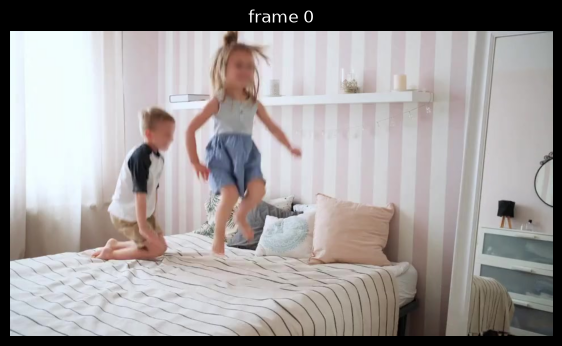

In [3]:
BEDROOM = Path("notebooks/videos/bedroom")
N_FRAMES = 30  # first N frames; the clip has 200

frame_paths = sorted(BEDROOM.glob("*.jpg"))[:N_FRAMES]
frames = [np.asarray(Image.open(p).convert("RGB")) for p in frame_paths]
H, W, _ = frames[0].shape
print(f"{len(frames)} frames @ {W}x{H}")

plt.figure(figsize=(7, 4))
plt.title("frame 0")
plt.imshow(frames[0])
plt.axis("off")
plt.show()

## 1. Non-multiplex SAM 3 — text-concept video tracking

Composes the shared PE encoder + text tower + DETR detector + per-object tracker from
`configs/sam3/sam3.yaml` and strict-loads `checkpoints/sam3.pt`. Set the text concept **once**
before the first frame, then call `forward(state, i, frame)` per frame; each call returns
`dict[obj_id -> MaskletResult]`.

In [4]:
from sam.build_sam import build_sam3_video_predictor
from sam.models.sam3_predictor import Sam3VideoPredictorState
from sam.prompts import ConceptPrompt, GeometryPrompt

video_predictor = build_sam3_video_predictor(
    config_file="configs/sam3/sam3.yaml",
    ckpt_path="checkpoints/sam3.pt",
    device="cuda",
)
print(f"loaded: {sum(p.numel() for p in video_predictor.parameters()) / 1e6:.0f}M params")

loaded: 860M params


tracked ids on last frame: [0, 1]


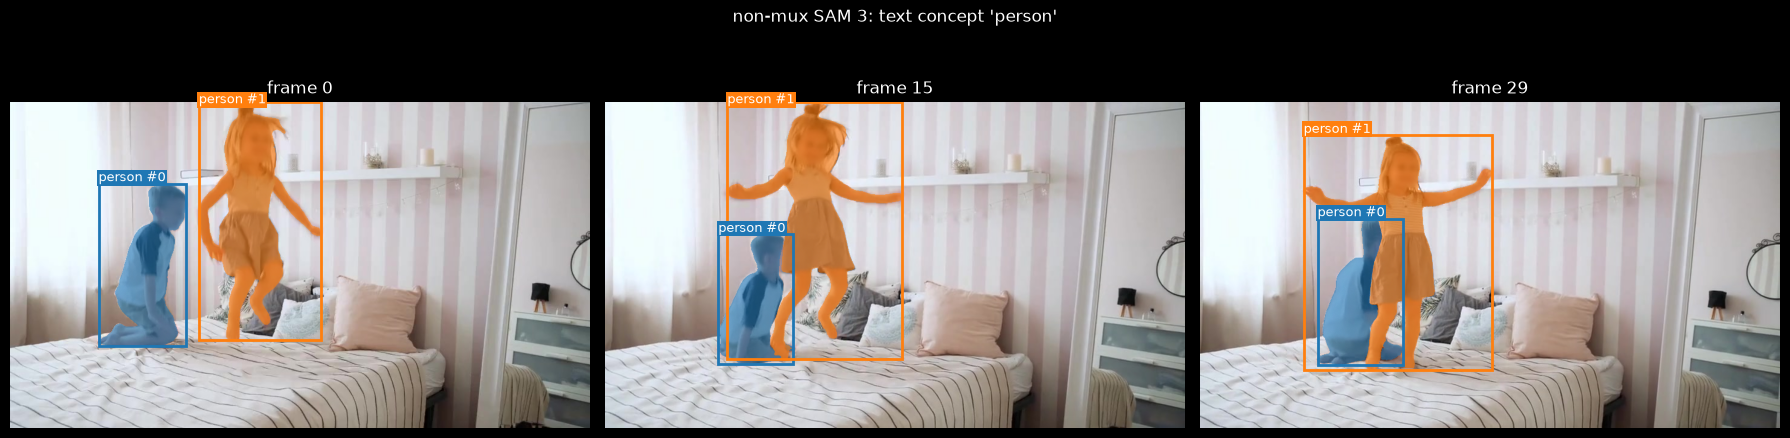

In [5]:
CONCEPT = "person"

state = Sam3VideoPredictorState(video_hw=(H, W))
video_predictor.set_concept(state, ConceptPrompt(CONCEPT))
text_track = collect(video_predictor, state, frames)
print(f"tracked ids on last frame: {sorted(text_track[-1])}")
show_tracking(frames, text_track, f"non-mux SAM 3: text concept '{CONCEPT}'", CONCEPT)

### Geometry prompting (click / box) — interactive VOS, no text

The **non-mux** video predictor also accepts `GeometryPrompt`s: a click (or box) on a frame
spawns / refines an object, which is then tracked SAM 2-style. Here we set **no** concept and
seed a single positive click on frame 0 (`label=1`), so only that object is tracked.

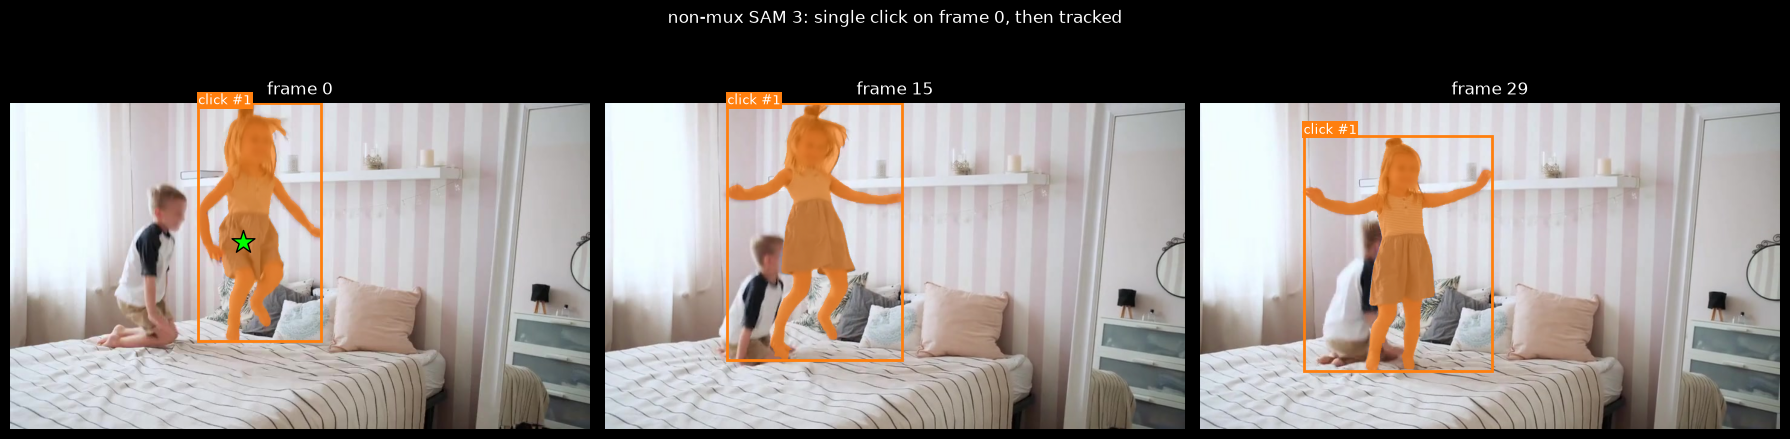

In [6]:
CLICK_XY = (385.0, 230.0)  # a kid in the 960x540 frame

click = GeometryPrompt(
    obj_id=1,
    points_coords=torch.tensor([list(CLICK_XY)], device=device),
    points_labels=torch.tensor([1], device=device),
)
state = Sam3VideoPredictorState(video_hw=(H, W))  # fresh state, NO set_concept
click_track = collect(video_predictor, state, frames, geometry_prompts_frame0=[click])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("non-mux SAM 3: single click on frame 0, then tracked")
for ax, i in zip(axes, [0, 15, 29]):
    ax.set_title(f"frame {i}")
    ax.imshow(frames[i])
    ax.axis("off")
    for obj_id, o in click_track[i].items():
        show_mask(o["mask"], ax, obj_id=obj_id)
        if o["box"] is not None:
            show_box(o["box"], ax, obj_id=obj_id, label=f"click #{obj_id}")
    if i == 0:
        ax.scatter(*CLICK_XY, color="lime", marker="*", s=300, edgecolor="black", zorder=5)
plt.tight_layout()
plt.show()

## 2. Non-multiplex SAM 3 — image detection (genuine DETR boxes)

The video tracker has no box head, so the boxes above are mask-derived. To see SAM 3's **real
predicted boxes**, run the image detector on a single frame: `Sam3DetectionResult.boxes` are the
raw DETR `pred_boxes` (cxcywh -> xyxy, scaled to pixels).

2 detection(s) | presence=0.970
boxes (xyxy px) = raw DETR pred_boxes:
[[146.6 134.7 291.  405.7]
 [310.3  -1.  515.2 396.8]]


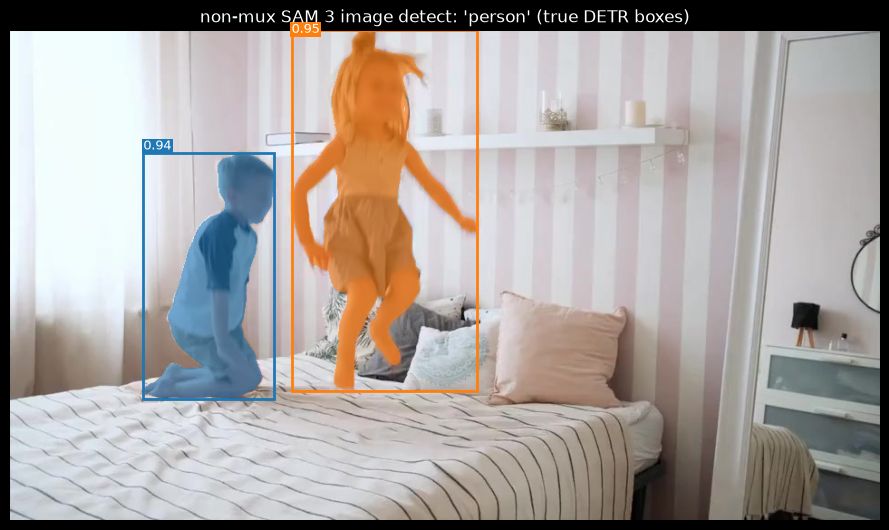

In [7]:
from sam.build_sam import build_sam3

del video_predictor, state  # free the video weights first (SAM 3 is large)
torch.cuda.empty_cache()

image_predictor = build_sam3(
    config_file="configs/sam3/sam3.yaml", ckpt_path="checkpoints/sam3.pt", device="cuda",
)

det = image_predictor.predict(frames[0], ConceptPrompt(CONCEPT), confidence_threshold=0.5)
print(f"{det.num_detections} detection(s) | presence={det.presence:.3f}")
print("boxes (xyxy px) = raw DETR pred_boxes:")
print(det.boxes.cpu().numpy().round(1))

fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.set_title(f"non-mux SAM 3 image detect: '{CONCEPT}' (true DETR boxes)")
ax.imshow(frames[0])
ax.axis("off")
for i in range(det.num_detections):
    show_mask((det.masks_logits[i] > 0).cpu(), ax, obj_id=i)
    show_box(det.boxes[i], ax, obj_id=i, label=f"{det.scores[i]:.2f}")
plt.tight_layout()
plt.show()

### Text-prompt variety & confidence threshold

The concept is just a phrase — swap it to detect anything. `confidence_threshold` trades recall
for precision (presence-weighted score gate).

In [8]:
for phrase in ["person", "bed", "lamp", "window", "picture frame"]:
    d = image_predictor.predict(frames[0], ConceptPrompt(phrase), confidence_threshold=0.5)
    print(f"{phrase:<14} -> {d.num_detections:2d} detection(s) | presence={d.presence:.3f}")

print("\nconfidence_threshold sweep for 'person':")
for thr in [0.3, 0.5, 0.7, 0.9]:
    d = image_predictor.predict(frames[0], ConceptPrompt("person"), confidence_threshold=thr)
    print(f"  thr={thr} -> {d.num_detections} detection(s)")

person         ->  2 detection(s) | presence=0.970
bed            ->  1 detection(s) | presence=0.965
lamp           ->  1 detection(s) | presence=0.745
window         ->  0 detection(s) | presence=0.050
picture frame  ->  0 detection(s) | presence=0.036

confidence_threshold sweep for 'person':
  thr=0.3 -> 2 detection(s)
  thr=0.5 -> 2 detection(s)
  thr=0.7 -> 2 detection(s)
  thr=0.9 -> 2 detection(s)


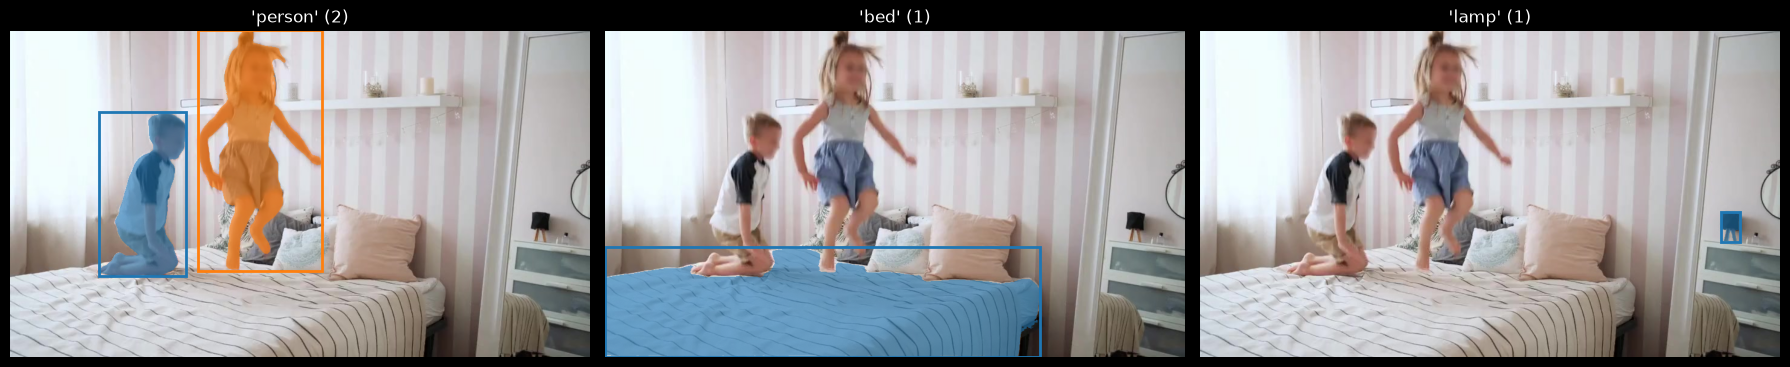

In [9]:
concepts = ["person", "bed", "lamp"]
fig, axes = plt.subplots(1, len(concepts), figsize=(6 * len(concepts), 5))
for ax, phrase in zip(np.atleast_1d(axes), concepts):
    d = image_predictor.predict(frames[0], ConceptPrompt(phrase), confidence_threshold=0.5)
    ax.set_title(f"'{phrase}' ({d.num_detections})")
    ax.imshow(frames[0])
    ax.axis("off")
    for i in range(d.num_detections):
        show_mask((d.masks_logits[i] > 0).cpu(), ax, obj_id=i)
        show_box(d.boxes[i], ax, obj_id=i)
plt.tight_layout()
plt.show()

## 3. Multiplex SAM 3.1 — text-concept video tracking

Same `set_concept` / `forward` API, but `build_sam3_multiplex_video_predictor` swaps in the
SAM 3.1 tri-neck encoder, joint-score detector, and the multiplex tracker (objects packed into
K=16 buckets, tracked jointly). Config `configs/sam3/sam3.1.yaml`, checkpoint
`checkpoints/sam3.1_multiplex.pt` (~3.3 GB). **Geometry prompts are not supported here** (the mux
`forward` raises `NotImplementedError`); use the base predictor for click/box.

In [10]:
from sam.build_sam import build_sam3_multiplex_video_predictor

del image_predictor  # free non-mux weights before loading the larger mux checkpoint
torch.cuda.empty_cache()

mux_predictor = build_sam3_multiplex_video_predictor(
    config_file="configs/sam3/sam3.1.yaml",
    ckpt_path="checkpoints/sam3.1_multiplex.pt",
    device="cuda",
)
print(f"loaded: {sum(p.numel() for p in mux_predictor.parameters()) / 1e6:.0f}M params")

loaded: 873M params


tracked ids on last frame: [0, 1]


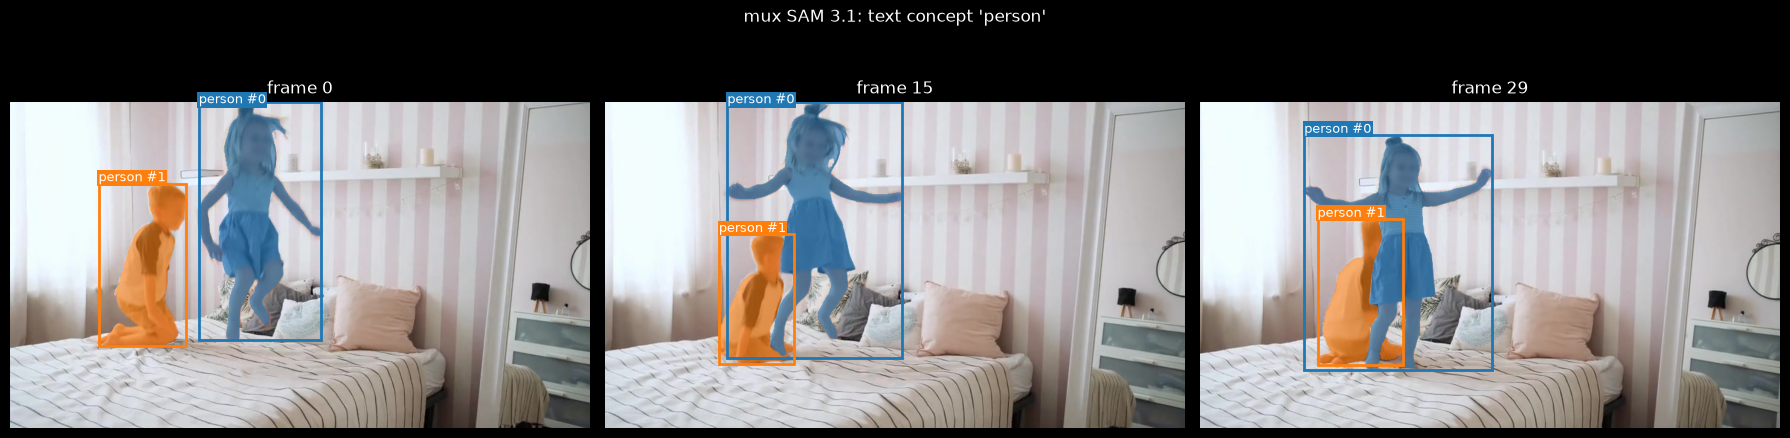

In [11]:
state = Sam3VideoPredictorState(video_hw=(H, W))
mux_predictor.set_concept(state, ConceptPrompt(CONCEPT))
mux_track = collect(mux_predictor, state, frames)
print(f"tracked ids on last frame: {sorted(mux_track[-1])}")
show_tracking(frames, mux_track, f"mux SAM 3.1: text concept '{CONCEPT}'", CONCEPT)

### Interactive seed-frame click (mux, text-free)

A positive click on frame 0 seeds an object, then it tracks forward — the SAM 3.1
interactive VOS path (`interactive_sam_prompt_encoder` + `interactive_sam_mask_decoder`),
no text concept. Box output is the mask-derived box, as before.

In [ ]:
st_click = Sam3VideoPredictorState(video_hw=(H, W))
click = GeometryPrompt(
    obj_id=1,
    points_coords=torch.tensor([[385.0, 230.0]], device=device),
    points_labels=torch.tensor([1], device=device),
)
mux_click = collect(mux_predictor, st_click, frames, geometry_prompts_frame0=[click])
print(f"tracked ids on last frame: {sorted(mux_click[-1])}")
show_tracking(frames, mux_click, "mux SAM 3.1: seed-frame click", "click")

### Model-find: mid-stream detector spawn (dynamic add)

Text `"person"` on `dance.mp4`: the camera pans, a dancer leaves frame, then
**re-enters mid-video** and the detector auto-spawns a tracklet — the multiplex
state grows mid-stream (no re-seed). Watch the object count drop then rise.

In [ ]:
dance = [
    np.asarray(Image.open(f"notebooks/videos/dance/{i:05d}.jpg").convert("RGB"))
    for i in range(101)
]
dh, dw, _ = dance[0].shape
st_mf = Sam3VideoPredictorState(video_hw=(dh, dw))
mux_predictor.set_concept(st_mf, ConceptPrompt("person"))
mf = collect(mux_predictor, st_mf, dance)
print("tracked-object count by frame:",
      {i: len(mf[i]) for i in (0, 60, 90, 96, 100)})
show_tracking(dance, mf, "mux SAM 3.1 model-find: 'person' (re-entrant mid-video)",
              "person", idxs=[0, 90, 97, 100])

## Summary

- **Text concept** works on all three paths (non-mux image / non-mux video / mux video) via
  `ConceptPrompt(text)` — the phrase is the prompt.
- **Geometry** (click/box, `GeometryPrompt`): the **non-mux video** predictor takes points,
  boxes and masks; the **mux (3.1)** predictor takes seed-frame point clicks (text+click
  co-seed and mid-stream add are not yet wired; boxes/masks route to the exemplar path).
- **Genuine boxes** come only from the **image detector** (`Sam3DetectionResult.boxes` = DETR
  `pred_boxes`). Both video paths emit masks; the boxes shown for video are `masks_to_boxes`
  derived **in this notebook** — no library change.
- `ConceptPrompt.negative_phrases` / `exemplars` are accepted by the API but currently deferred
